Sources:

mehta

A Practical Guide to Training Restricted Boltzmann Machines https://link.springer.com/chapter/10.1007/978-3-642-35289-8_32 (versione aggiornata del paper della Siloi)


# Dataset loading

The MNIST dataset comprises 70000 handwritten digits, each of which comes in a square image, divided into a 28×28 pixel grid. Every pixel can take on 256 nuances of the grey colour, interpolating between white and black, and hence each data point assumes any value in the set {0,1,…,255}. There are 10 categories in the problem, corresponding to the ten digits.


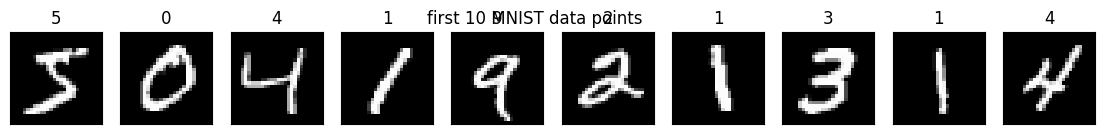

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.datasets import fetch_openml

# Load dataset
X_original, Y_original = fetch_openml("mnist_784", version=1, return_X_y=True, as_frame=False)

def plot_digits(digit_matrices, digit_labels, plot_count, fig_title, colors=[]):

    if len(digit_labels) == 0:
        digit_labels = np.full(plot_count,"")
    colors = np.array(colors)
    
    fig, axes = plt.subplots(1,plot_count,figsize=(1.4*plot_count, 1.4))
    fig.suptitle(fig_title)
    
    side = int(digit_matrices.shape[1]**0.5)
    for i, img in enumerate(digit_matrices[:plot_count].reshape(plot_count, side, side)):
        if len(colors) == 0:
            newcmp = "grey"
        else:
            col = colors[0] + (colors[1]-colors[0])*(i+1)/(plot_count+1)
            newcmp = ListedColormap((col,(1,1,1,1)))
        ax = axes[i]
        ax.imshow(img, cmap=newcmp)
        ax.set_xticks([])
        ax.set_yticks([])
        if len(digit_labels) > 0:
            ax.set_title(digit_labels[i])
    plt.show()

plot_digits(X_original, Y_original, plot_count=10, fig_title="first 10 MNIST data points")

# Dataset choice and preprocessing

RBM’s were developed using binary visible and hidden units, but many other
types of unit can also be used. A general treatment for units in the exponential
family is given in [24]. The main use of other types of unit is for dealing with
data that is not well-modeled by binary (or logistic) visible units

for now, we binarize the images by setting each pixel black or white based on intensity greater or lower than 0.5

The more diverse are the digits in
the set, the harder is the learning task.
for now, we choose digits 0,1,2



dataset with 21770 points, each with 784 bits



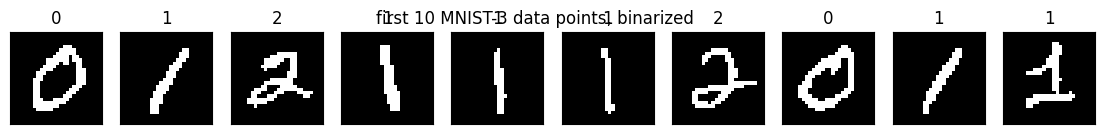

In [2]:
def binarize(X, side=28, threshold=0.5):
    NX=len(X)
    
    print(f"dataset with {NX} points, each with {len(X[0])} bits\n")
    if side == 14:
        X = np.reshape(X, (NX,28,28))
        # new value = average over 4 values in a 2x2 square
        Xr = 0.25*(X[:,0::2,0::2]+X[:,1::2,0::2]+X[:,0::2,1::2]+X[:,1::2,1::2])
        X  = Xr.reshape(NX,side**2)
    
    # binarize data and then convert it to 1/0 or 1/-1
    X = np.where(X/255 > threshold, UNIT_ON, UNIT_OFF)
    return X.astype("int")


SPINS = False

UNIT_OFF = -1 if SPINS else 0
UNIT_ON = 1

NUM_VISIBLE_UNITS = 28*28
NUM_HIDDEN_UNITS = 12

num_digits = 3
list_10_digits = ('0','1','2','3','4','5','6','7','8','9')
list_digits = list_10_digits[:num_digits]
working_mask = np.isin(Y_original, list_digits)
X_working, Y_working = X_original[working_mask], Y_original[working_mask]
data, labels = binarize(X_working), Y_working

plot_digits(data, labels,plot_count=10, fig_title=f"first 10 MNIST-{num_digits} data points, binarized")

# RBM model definition

A Restricted Boltzmann Machine (RBM) is an energy-based model with both visible and hidden units where the visible
and hidden units interact with each other but do not interact among themselves. The energy function of an RBM takes
the general functional form
$ E(v, h) = - a(v) - b(h) - v^\intercal W h $
where $a\colon R^M \to R$ and $a\colon R^L \to R$ are functions that we are free to choose, $M, L$ the number of visible, hidden units resp.

For binary values The most common choice is: $a(v) = a^\intercal v$, $b(h) = b^\intercal h$ (Bernoulli layers)

For our images $L = 28*28 = 784$

Our energy function is then $E(v, h) = - v^\intercal W h - a^\intercal v - b^\intercal h, v\in \{0,1\}^{784}, h\in\{0,1\}^L$

An RBM can have different properties depending on whether the hidden and visible layers are taken to be Bernoulli
or Gaussian. The most common choice is to have both the visible and hidden units be Bernoulli. This is what is typically
meant by an RBM. However, other combinations are also possible and used in the ML literature. When all the units are
continuous, the RBM reduces to a multi-dimensional Gaussian with a very particular correlation structure. When the
hidden units are continuous and the visible units are discrete, the RBM is equivalent to a generalized Hopfield model
(see discussion above). When the visible units are continuous and the hidden units are discrete, the RBM is often called a
Gaussian Bernoulli Restricted Boltzmann Machine (Dahl et al., 2010; Hinton and Salakhutdinov, 2006). It is even possible
to perform multi-modal learning with a mixture of continuous and discrete variables. For all these architectures, the
important point is that all interactions occur only between the visible and hidden units and there are no interactions
between units within the hidden or visible layers,

The network assigns a
probability to every possible pair of a visible and a hidden vector via this energy
function:$ p(v, h) = \frac{1}{Z} e^{-E(v,h)}$


The derivative of the log
probability of a training vector with respect to a weight is surprisingly simple.
This leads to a very simple learning rule
for performing stochastic steepest ascent in the log probability of the training
data: $\Delta W_{ij} = \epsilon(\langle v_i h_j \rangle_\text{data} − \langle v_i h_j \rangle_\text{model})$

Because there are no direct connections between hidden units in an RBM, it
is very easy to get an unbiased sample of $\langle v_i h_j \rangle_\text{data} $

Getting an unbiased sample of $\langle v_i h_j \rangle_\text{model} $, however, is much more difficult. It
can be done by starting at any random state of the visible units and perform-
ing alternating Gibbs sampling for a very long time. One iteration of alternating
Gibbs sampling consists of updating all of the hidden units in parallel using equa-
tion 24.7 followed by updating all of the visible units in parallel using equation
24.8.
A much faster learning procedure was proposed in [5]. This starts by setting
the states of the visible units to a training vector. Then the binary states of the
hidden units are all computed in parallel using equation 24.7. Once binary states
have been chosen for the hidden units, a “reconstruction” is produced by setting
each vi to 1 with a probability given by equation 24.8. The change in a weight
is then given by $\Delta W_{ij} = \epsilon(\langle v_i h_j \rangle_\text{data} − \langle v_i h_j \rangle_\text{recon})$
A simplified version of the same learning rule that uses the states of individual
units instead of pairwise products is used for the biases.
The learning works well even though it is only crudely approximating the
gradient of the log probability of the training data

CDn will be used to denote
learning using n full steps of alternating Gibbs sampling.

One drawback of Gibbs sampling is that it may take many back and forth iterations to draw an independent sample.
For this reason, the Hinton group introduced an approximate Gibbs sampling technique called Contrastive Divergence
(CD) (Hinton, 2002; Hinton et al., 2006). In CD-n, we just perform n iterations of (block) Gibbs sampling, with n often
taken to be as small as 1 (see Fig. 62)! The price for this truncation is, of course, that we are not drawing samples from
the true model distribution. But for our purpose – using the expectations to estimate the gradient for SGD – CD-n has
proven to work reasonably well.

$\langle v_i h_j \rangle_\text{data}$ is called positive statistic
$\langle v_i h_j \rangle_\text{recon})$ is called negative statistic

In [6]:

def sigmoid(x):
    return 1. / (1. + np.exp(-x))

def get_other_layer(this_layer_state, weights, bias, binarize):
    total_input = np.clip(np.dot(this_layer_state, weights) + bias, a_min=-300, a_max=300) # why clipping?

    activation_prob = sigmoid(total_input * (UNIT_ON - UNIT_OFF))
    if not binarize:
        other_layer_state = activation_prob
        return other_layer_state
    else:
        num_units = total_input.shape[0]
        other_layer_state = np.full(num_units, UNIT_OFF, dtype=int)
        other_layer_state[np.random.random(num_units) < activation_prob] = UNIT_ON
        return other_layer_state


def CD_k(k, initial_visible_layer_state, weights, visible_layer_bias, hidden_layer_bias):
    visible_layer_state = initial_visible_layer_state
    for cd_step in range(k):
        # It is very important to make these hidden states binary, so binarize=True (Hinton 24.3.1)
        hidden_layer_state = get_other_layer(visible_layer_state, weights, hidden_layer_bias, binarize=True)
        #  it is common to use the probability instead of sampling a binary value for the visible layer, so binarize=False (Hinton 24.3.2)
        visible_layer_bias = get_other_layer(hidden_layer_state, weights.T, visible_layer_bias, binarize=False)
    
    # For the last update of the hidden units, it is silly to use stochastic binary states (Hinton 24.3.1)
    hidden_layer_state = get_other_layer(visible_layer_state, weights, hidden_layer_bias, binarize=False)
    
    return visible_layer_state, hidden_layer_state


Monitor Gradient RMS
The gradient measures how much the weights should be adjusted to reduce the error.
RMS (Root Mean Square) of the gradient tells you how big the weight updates are.
If the RMS is too high, it suggests the model is making too large updates and could be unstable.
If the RMS is too low, it might indicate that the model is learning too slowly or not updating much.

You want to monitor this during training to make sure things are progressing smoothly.


Visualizing Learned Weights

Once the model starts to learn, you can visualize the weights between the visible and hidden layers. Since the visible layer is 784-dimensional (28x28 pixels), each hidden unit has a 784-dimensional weight vector. When you reshape this vector into a 28x28 image, it shows you what kind of feature the hidden unit has learned.

Good training will show clear, interpretable patterns (like edges, loops, or strokes) in the weights.


Testing Generative Behavior
The RBM can generate new samples once trained. This means that, after training, the RBM should be able to create new, realistic images of digits.

Two ways to test this:
Gibbs Sampling:
Start with random noise in the visible layer.
Use alternating updates between the visible and hidden layers to gradually make the sample more realistic (this is the "sampling" process).

After running enough Gibbs steps, the model should output something that resembles a digit.

Reconstruction:
Take a real image of a digit from the test set.
Pass it through the network to generate a reconstructed version of it.
Compare the original image with the reconstruction to measure how well the model learned to represent the data.

Experiment: Vary One Parameter

Once the basic RBM is working, you can experiment with different parameters to see how they affect the training:

(A) Number of Hidden Units (H)
A larger number of hidden units lets the model capture more complex patterns, but it may also overfit or make training slower.
Too few hidden units won’t be able to capture enough features of the data.
(B) Learning Rate (η)
A small learning rate causes slow learning, while a large learning rate can make the training unstable.
Try adjusting it to see how it affects convergence speed and stability.
(C) Number of Contrastive Divergence Steps (k)
With more steps (e.g., CD-5), the approximation is more accurate but training takes longer.
CD-1 is faster but may not capture the true data distribution as well.
(D) Weight Decay (Regularization)
Adding a small penalty on large weights can help the model generalize better and avoid overfitting.

In [4]:
def plot_weights_and_bias(weights, bias, fig_title, save=True, cmap="bwr"):
    num_cols = 8
    num_hidden_units = weights.shape[1]
    num_rows = int(np.ceil(float(num_hidden_units) / num_cols))
    fig, axes = plt.subplots(num_rows, num_cols + 1, figsize=(1.5 * (1 + num_cols), 1.5 * num_rows))
    fig.suptitle(fig_title)

    side = int(np.sqrt(len(weights)))

    bias_ax = axes[0, 0]
    im = bias_ax.imshow(bias.reshape(side, side), cmap=cmap)
    bias_ax.set_xticks([])
    bias_ax.set_yticks([])
    bias_ax.set_title("bias")

    for row_id in range(num_rows):
        for col_id in range(num_cols):
            if num_rows == 1:
                ax = axes[col_id + 1]
            else:
                ax = axes[row_id, col_id + 1]

            ax_id = row_id * (num_cols + 1) + (col_id + 1)
            if ax_id > num_hidden_units:
                fig.delaxes(ax)
                continue

            ax.imshow(weights[:,ax_id-1].reshape(side, side), cmap=cmap)
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_title(f"hidden {ax_id}")
            
        if row_id > 0:
            fig.delaxes(axes[row_id, 0])

    # colobar
    cbar_ax = fig.add_axes([0.14, 0.15, 0.024, 0.33])
    cbar = fig.colorbar(im, cax=cbar_ax)
    cbar.ax.tick_params(labelsize=12)
    
    S=0.3
    plt.subplots_adjust(hspace=S)

    if save: plt.savefig(f"./FIG/FRAME/RBM_{fig_title}_w-a.png")

    plt.show()
    plt.close()


# Train

Training with stochastic gradient descent means we will be using small minibatches of data to compute the gradient at each step. If the data have an order, then the estimates for the gradients computed from the minibatches will be biased. Shuffling the data ensures that the gradient estimates are unbiased (though still noisy).

Nepoch=150
Nmini=20
Starting the training
[13219  2716  4920  6568 13003 11410  8551 16753  2909 14542]
[15192 12747 13630  3626  1397 18827 19099 21305 11357  9055]
[ 6248 14283 16751 17339 19024  1049  3317  8426 17034  3772]
[17686  2984 14871 13123   281 13178  7789  3118 17416 18200]
epoch 1 / 150  CD steps: 2  batch size: 10  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 2 / 150  CD steps: 2  batch size: 10  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 3 / 150  CD steps: 2  batch size: 10  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 4 / 150  CD steps: 2  batch size: 10  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 5 / 150  CD steps: 2  batch size: 10  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 6 / 150  CD steps: 2  batch size: 10  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 7 / 150  CD steps: 2  batch size: 10  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= Fa

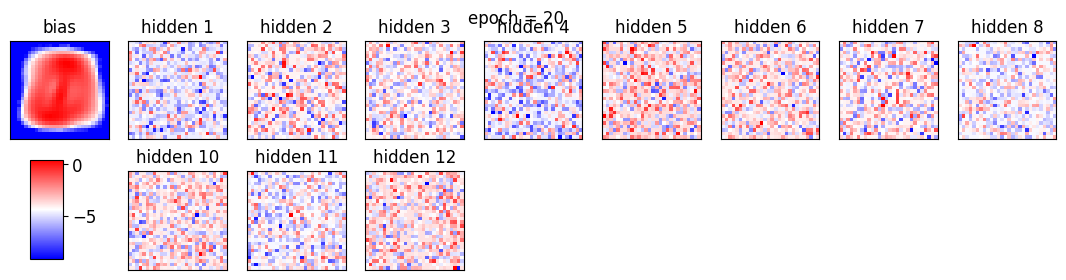

epoch 21 / 150  CD steps: 2  batch size: 18  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 22 / 150  CD steps: 2  batch size: 19  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 23 / 150  CD steps: 2  batch size: 20  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 24 / 150  CD steps: 2  batch size: 21  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 25 / 150  CD steps: 2  batch size: 22  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 26 / 150  CD steps: 2  batch size: 23  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 27 / 150  CD steps: 2  batch size: 24  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 28 / 150  CD steps: 2  batch size: 26  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 29 / 150  CD steps: 2  batch size: 27  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 30 / 150  CD steps: 2  batch size: 28  NUM_HIDDEN_UNITS: 12  rate: 

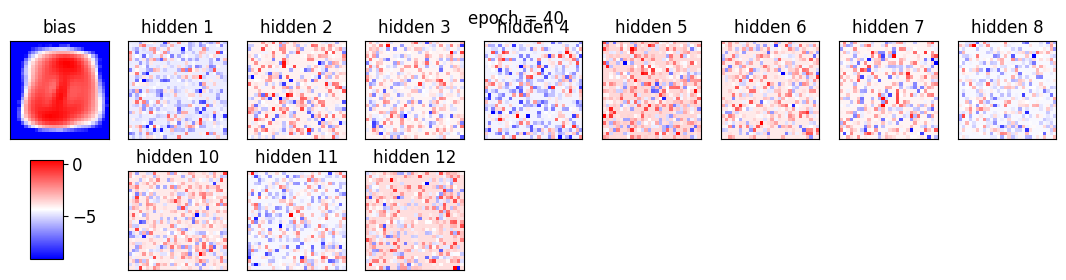

epoch 41 / 150  CD steps: 2  batch size: 45  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 42 / 150  CD steps: 2  batch size: 47  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 43 / 150  CD steps: 2  batch size: 48  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 44 / 150  CD steps: 2  batch size: 50  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 45 / 150  CD steps: 2  batch size: 52  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 46 / 150  CD steps: 2  batch size: 54  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 47 / 150  CD steps: 2  batch size: 56  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 48 / 150  CD steps: 2  batch size: 58  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 49 / 150  CD steps: 2  batch size: 60  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 50 / 150  CD steps: 2  batch size: 62  NUM_HIDDEN_UNITS: 12  rate: 

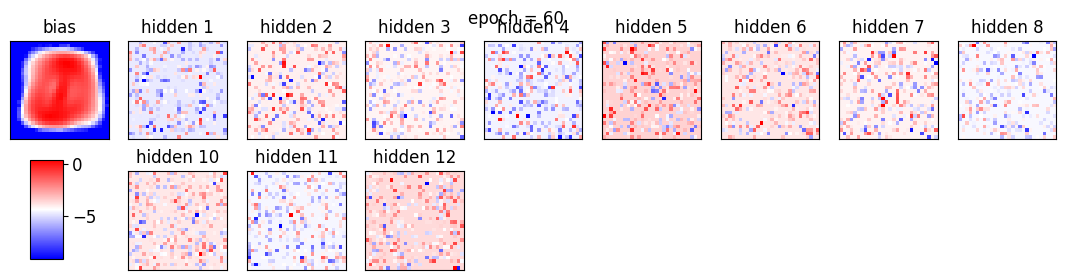

epoch 61 / 150  CD steps: 2  batch size: 89  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 62 / 150  CD steps: 2  batch size: 92  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 63 / 150  CD steps: 2  batch size: 94  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 64 / 150  CD steps: 2  batch size: 97  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 65 / 150  CD steps: 2  batch size: 100  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 66 / 150  CD steps: 2  batch size: 103  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 67 / 150  CD steps: 2  batch size: 106  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 68 / 150  CD steps: 2  batch size: 109  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 69 / 150  CD steps: 2  batch size: 112  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 70 / 150  CD steps: 2  batch size: 115  NUM_HIDDEN_UNITS: 12  

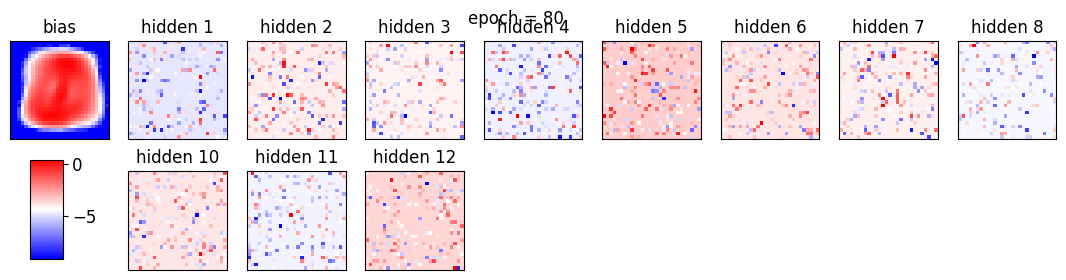

epoch 81 / 150  CD steps: 2  batch size: 151  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 82 / 150  CD steps: 2  batch size: 154  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 83 / 150  CD steps: 2  batch size: 158  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 84 / 150  CD steps: 2  batch size: 162  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 85 / 150  CD steps: 2  batch size: 165  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 86 / 150  CD steps: 2  batch size: 169  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 87 / 150  CD steps: 2  batch size: 173  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 88 / 150  CD steps: 2  batch size: 177  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 89 / 150  CD steps: 2  batch size: 180  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 90 / 150  CD steps: 2  batch size: 184  NUM_HIDDEN_UNITS: 

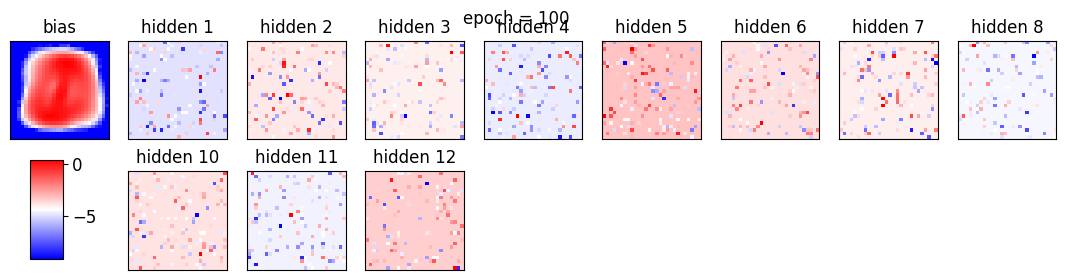

epoch 101 / 150  CD steps: 2  batch size: 230  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 102 / 150  CD steps: 2  batch size: 235  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 103 / 150  CD steps: 2  batch size: 239  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 104 / 150  CD steps: 2  batch size: 244  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 105 / 150  CD steps: 2  batch size: 248  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 106 / 150  CD steps: 2  batch size: 253  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 107 / 150  CD steps: 2  batch size: 257  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 108 / 150  CD steps: 2  batch size: 262  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 109 / 150  CD steps: 2  batch size: 267  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 110 / 150  CD steps: 2  batch size: 272  NUM_HIDD

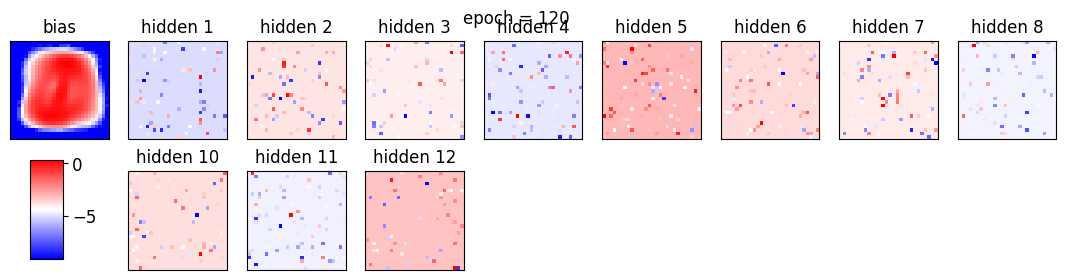

epoch 121 / 150  CD steps: 2  batch size: 327  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 122 / 150  CD steps: 2  batch size: 333  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 123 / 150  CD steps: 2  batch size: 338  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 124 / 150  CD steps: 2  batch size: 343  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 125 / 150  CD steps: 2  batch size: 349  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 126 / 150  CD steps: 2  batch size: 354  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 127 / 150  CD steps: 2  batch size: 360  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 128 / 150  CD steps: 2  batch size: 365  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 129 / 150  CD steps: 2  batch size: 371  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 130 / 150  CD steps: 2  batch size: 377  NUM_HIDD

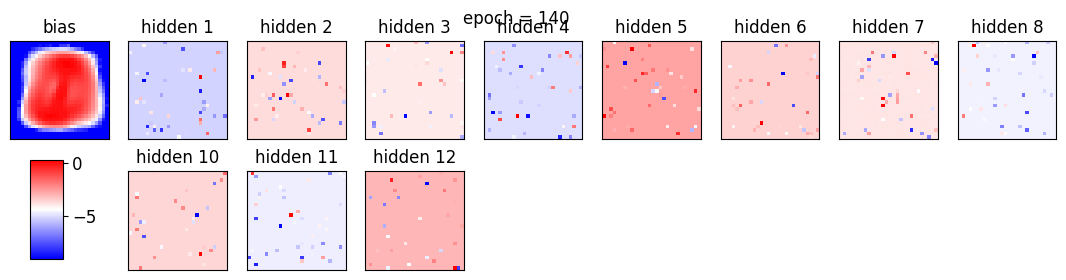

epoch 141 / 150  CD steps: 2  batch size: 442  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 142 / 150  CD steps: 2  batch size: 448  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 143 / 150  CD steps: 2  batch size: 455  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 144 / 150  CD steps: 2  batch size: 461  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 145 / 150  CD steps: 2  batch size: 467  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 146 / 150  CD steps: 2  batch size: 474  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 147 / 150  CD steps: 2  batch size: 480  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 148 / 150  CD steps: 2  batch size: 486  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 149 / 150  CD steps: 2  batch size: 493  NUM_HIDDEN_UNITS: 12  rate: 0.05  gam: 0.001 SPINS= False
epoch 150 / 150  CD steps: 2  batch size: 500  NUM_HIDD

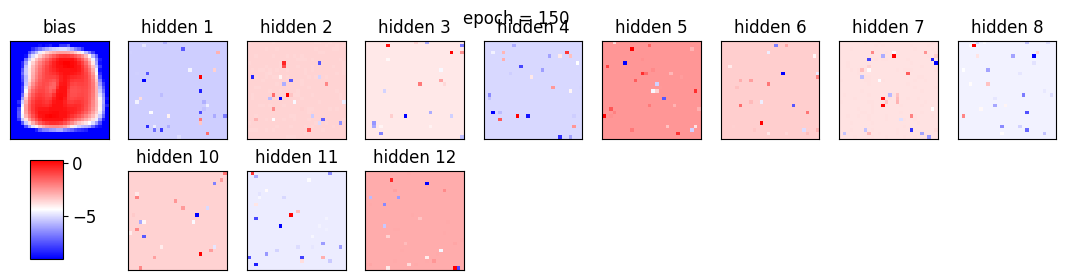

END of learning phase


In [7]:
# random seed for reproducibility
np.random.seed(12345)

# initial bias of visible units, based on their average value in the dataset
# Hinton, "A Practical Guide to Training Restricted Boltzmann Machines"
def Hinton_bias_init(x):
    xmean = np.array(np.mean(x, axis = 0))
    # remove values at extrema, to avoid divergences in the log's
    S = 1e-4
    min_value, max_value = UNIT_OFF + S, UNIT_ON - S
    xmean[xmean < min_value] = min_value
    xmean[xmean > max_value] = max_value
    return (np.log(xmean - UNIT_OFF) - np.log(UNIT_ON - xmean)) / (UNIT_ON - UNIT_OFF)
    
# range of each initial weight
# Glorot and Bengio, "Understanding the difficulty of training deep feedforward neural networks"
sigma = np.sqrt(4. / float(NUM_HIDDEN_UNITS + NUM_VISIBLE_UNITS))

# initial weights from a Normal distr. (see literature, e.g. page 98 of Mehta's review)
w = sigma * np.random.randn(NUM_VISIBLE_UNITS, NUM_HIDDEN_UNITS)

# using Hinton initialization of visible biases
v_bias = Hinton_bias_init(data)
# hidden biases initialized to zero
h_bias = np.zeros(NUM_HIDDEN_UNITS)

# nr of epochs
num_epochs=150
# minibatches per epoch
num_batches_per_epoch=20
# minibatch size at initial epoch and final one
initial_batch_size, final_batch_size = 10, 500
print(f"Nepoch={num_epochs}\nNmini={num_batches_per_epoch}")
# number of CD steps
NUM_CD_STEPS = 2

# Gradient descent options
GD_METHOD = "RMSprop"
if GD_METHOD == "SGD":
    initial_learning_rate = 1.0
    final_learning_rate = 0.25
elif GD_METHOD == "RMSprop":
    beta = 0.9
    epsilon = 1e-4
    initial_learning_rate = 0.05
    final_learning_rate = 0.05
    
    gw2,ga2,gb2 = np.zeros_like(w),np.zeros_like(v_bias),np.zeros_like(h_bias)
else:
    raise
GAMMA = 0.001 # for regularization

print("Starting the training")
# Note: here an epoch does not analyze the whole dataset
for epoch_id in range(1, 1 + num_epochs):
    # q maps epochs to interval [0,1]
    q = (epoch_id - 1.) / (num_epochs - 1.)

    # the learning rate grows linearly from the initial to the final value
    current_learning_rate = initial_learning_rate + (final_learning_rate - initial_learning_rate) * q
    # the number of batches grows quadratically from the initial to the final value
    current_batch_size = int(initial_batch_size + (final_batch_size - initial_batch_size) * q**2)

    for batch_id in range(num_batches_per_epoch):
        # Minibatch of size N: points randomply picked (without repetition) from data
        mini_batch = np.random.choice(len(data), current_batch_size, replace=False)
        if epoch_id == 1 and batch_id <= 3:
            print(mini_batch)

        avg_vi_data, avg_hj_data, avg_vi_hj_data = 0, 0, 0 # averages over the mini batch
        avg_vi_model, avg_hj_model, avg_vi_hj_model = 0, 0, 0

        for sample_id in range(current_batch_size):
            initial_visible_layer_state = data[mini_batch[sample_id]]

            vi_data = initial_visible_layer_state

            # Using hj is closer to the mathematical model of an RBM, but using pj usually has less sampling noise which allows slightly faster learning
            # so binarize=False (Hinton 24.3.3)
            hj_data = get_other_layer(initial_visible_layer_state, w, h_bias, binarize=False)
            vi_hj_data = np.outer(vi_data, hj_data)

            vi_model, hj_model = CD_k(NUM_CD_STEPS, initial_visible_layer_state, w, v_bias, h_bias)
            vi_hj_model = np.outer(vi_model, hj_model)

            avg_vi_data += vi_data / current_batch_size
            avg_hj_data += hj_data / current_batch_size
            avg_vi_hj_data += vi_hj_data / current_batch_size

            avg_vi_model += vi_model / current_batch_size
            avg_hj_model += hj_model / current_batch_size
            avg_vi_hj_model += vi_hj_model / current_batch_size

        # gradient ascent step
        gw = avg_vi_hj_data - avg_vi_hj_model
        ga = avg_vi_data - avg_vi_model
        gb = avg_hj_data - avg_hj_model
        if GD_METHOD == "SGD":
            w += current_learning_rate * gw
            v_bias += current_learning_rate * ga
            h_bias += current_learning_rate * gb
        elif GD_METHOD == "RMSprop":
            gw2 = beta * gw2 + (1-beta) * np.square(gw)
            ga2 = beta * ga2 + (1-beta) * np.square(ga)
            gb2 = beta * gb2 + (1-beta) * np.square(gb)
            w += current_learning_rate * gw / np.sqrt(epsilon + gw2)
            v_bias += current_learning_rate * ga / np.sqrt(epsilon + ga2)
            h_bias += current_learning_rate * gb / np.sqrt(epsilon + gb2)
        else:
            raise
        
        # regularization (LASSO)
        if GAMMA > 0.:
            w -= (GAMMA * current_learning_rate) * np.sign(w)
            v_bias -= (GAMMA * current_learning_rate) * np.sign(v_bias)
            h_bias -= (GAMMA * current_learning_rate) * np.sign(h_bias)

    print("epoch",epoch_id, "/", num_epochs," CD steps:",NUM_CD_STEPS," batch size:", current_batch_size," NUM_HIDDEN_UNITS:",NUM_HIDDEN_UNITS, " rate:",current_learning_rate, " gam:",GAMMA, "SPINS=",SPINS)

    if num_epochs <= 100 or epoch_id % 20==0 or epoch_id == num_epochs:
        plot_weights_and_bias(w, v_bias, f"epoch = {epoch_id}", save=False)

    #str_time_completion = datetime.datetime.now().strftime("_%Y%m%d_%H%M")

print("END of learning phase")
            